# Modeling Human Activity States Using Hidden Markov Models

**Group Members:** Mitali & Aubert  
**Devices:** Samsung SM-X216B (Tablet, Android) & iPhone 13 (iOS)  
**Sampling Rate:** 50 Hz (20ms) for both devices  

This notebook implements a complete HMM pipeline for human activity recognition using accelerometer and gyroscope data collected via the Sensor Logger app.

# 1. Imports and Setup

In [2]:
import numpy as np
import pandas as pd
import os
import glob
import warnings
from scipy.fft import fft, fftfreq
from scipy.stats import zscore
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

# Paths
ROOT_DIR = os.path.abspath('')
DATA_DIR = os.path.join(ROOT_DIR, 'dataset', 'dataset')
FIGURES_DIR = os.path.join(ROOT_DIR, 'figures')
os.makedirs(FIGURES_DIR, exist_ok=True)

# Activity mapping
ACTIVITY_MAP = {'Standing': 0, 'Walking': 1, 'Jumping': 2, 'Still': 3}
ACTIVITY_NAMES = ['Standing', 'Walking', 'Jumping', 'Still']
N_STATES = 4

print("Setup complete!")
print(f"Activities: {ACTIVITY_NAMES}")
print(f"Number of hidden states: {N_STATES}")
print(f"Data directory: {DATA_DIR}")
print(f"Figures directory: {FIGURES_DIR}")


Setup complete!
Activities: ['Standing', 'Walking', 'Jumping', 'Still']
Number of hidden states: 4
Data directory: /home/mitali/HMM-Human-Activity-Recognition/dataset/dataset
Figures directory: /home/mitali/HMM-Human-Activity-Recognition/figures


# 2. Data Loading & Preprocessing

We load accelerometer (x, y, z) and gyroscope (x, y, z) data from each recording.
Each recording was collected using the Sensor Logger app at 50 Hz sampling rate.
- **Mitali**: Samsung SM-X216B tablet (Android)
- **Aubert**: iPhone 13 (iOS)

Both devices were held in landscape mode against the abdomen for Standing, Walking,
and Jumping activities. For Still, devices were placed flat on a table.

In [3]:
def load_csv_pair(accel_path, gyro_path):
    """
    Load and merge a paired Accelerometer and Gyroscope CSV file.

    The Sensor Logger app exports columns: time, seconds_elapsed, z, y, x
    We rename axes to accel_x/y/z and gyro_x/y/z for clarity.
    Merging is done using merge_asof on seconds_elapsed (50 Hz → 20ms tolerance).
    """
    accel = pd.read_csv(accel_path)
    gyro  = pd.read_csv(gyro_path)

    # Rename spatial axes
    accel = accel.rename(columns={'x': 'accel_x', 'y': 'accel_y', 'z': 'accel_z'})
    gyro  = gyro.rename(columns={'x': 'gyro_x',  'y': 'gyro_y',  'z': 'gyro_z'})

    accel = accel[['seconds_elapsed', 'accel_x', 'accel_y', 'accel_z']].sort_values('seconds_elapsed').reset_index(drop=True)
    gyro  = gyro[['seconds_elapsed',  'gyro_x',  'gyro_y',  'gyro_z']].sort_values('seconds_elapsed').reset_index(drop=True)

    # Align gyro to accelerometer timestamps (tolerance = half a 50 Hz frame = 10ms)
    merged = pd.merge_asof(accel, gyro, on='seconds_elapsed', tolerance=0.025, direction='nearest')
    merged = merged.dropna().reset_index(drop=True)
    return merged


# ── Load all data ──────────────────────────────────────────────────────────────
# Dataset layout: dataset/dataset/{Activity}/{Person}_{Activity}_{N}_Accelerometer.csv
#                                            {Person}_{Activity}_{N}_Gyroscope.csv
all_samples = []
sample_info = []

for activity in sorted(os.listdir(DATA_DIR)):
    activity_path = os.path.join(DATA_DIR, activity)
    if not os.path.isdir(activity_path):
        continue

    accel_files = sorted(glob.glob(os.path.join(activity_path, '*_Accelerometer.csv')))

    for accel_path in accel_files:
        gyro_path = accel_path.replace('_Accelerometer.csv', '_Gyroscope.csv')
        if not os.path.exists(gyro_path):
            print(f"  [WARN] Missing gyro file for: {os.path.basename(accel_path)}")
            continue

        # Parse: {Person}_{Activity}_{Number}
        basename = os.path.basename(accel_path).replace('_Accelerometer.csv', '')
        parts = basename.split('_')
        person = parts[0]                           # e.g. "Mitali" or "Aubert"
        sample_id = basename                        # e.g. "Mitali_Jumping_1"

        df = load_csv_pair(accel_path, gyro_path)
        if df is None or len(df) < 10:
            print(f"  [WARN] Skipping {basename}: too few rows ({len(df) if df is not None else 0})")
            continue

        df['activity']  = activity
        df['person']    = person
        df['sample_id'] = sample_id
        all_samples.append(df)
        sample_info.append({
            'sample_id':  sample_id,
            'person':     person,
            'activity':   activity,
            'n_rows':     len(df),
            'duration_s': df['seconds_elapsed'].max() - df['seconds_elapsed'].min()
        })

info_df = pd.DataFrame(sample_info)
print(f"Total samples loaded: {len(all_samples)}")
print(f"\nSamples per person and activity:")
print(info_df.groupby(['person', 'activity']).size().unstack(fill_value=0))
print(f"\nDuration per activity (seconds):")
print(info_df.groupby('activity')['duration_s'].agg(['mean', 'min', 'max']).round(2))
print(f"\nRows per sample per activity (avg at 50 Hz):")
print(info_df.groupby('activity')['n_rows'].agg(['mean', 'min', 'max']))


Total samples loaded: 52

Samples per person and activity:
activity  Jumping  Standing  Still  Walking
person                                     
Aubert          6         7      6        6
Mitali          7         7      6        7

Duration per activity (seconds):
          mean   min   max
activity                  
Jumping   7.22  6.86  7.71
Standing  7.45  7.15  8.10
Still     7.34  7.12  7.58
Walking   7.38  6.99  7.66

Rows per sample per activity (avg at 50 Hz):
                mean  min  max
activity                      
Jumping   362.538462  344  388
Standing  374.357143  360  407
Still     369.083333  358  381
Walking   370.923077  352  383


## 2.1 Visualize Raw Sensor Data

Let's visualize sample recordings for each activity to understand the sensor patterns.

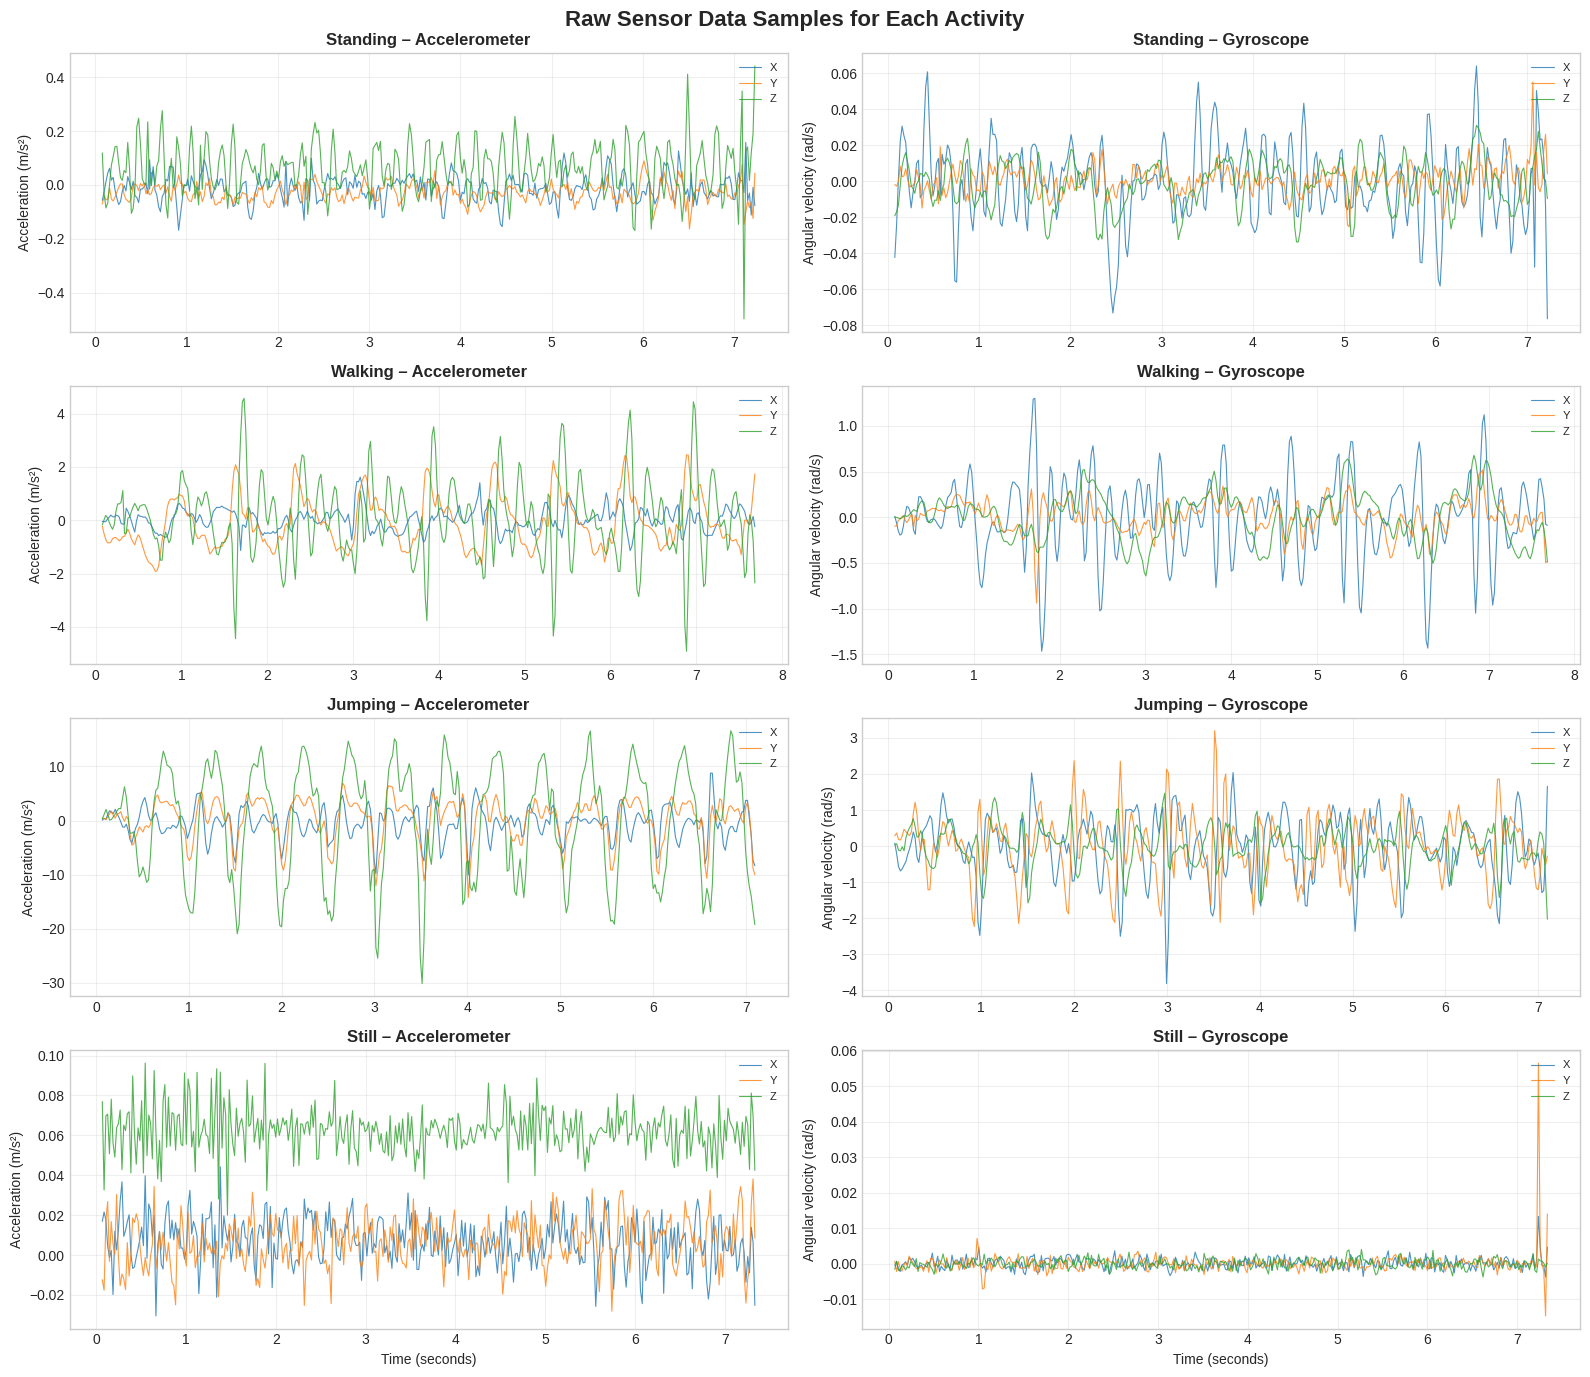

Figure saved: /home/mitali/HMM-Human-Activity-Recognition/figures/raw_sensor_data.png


In [4]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
fig.suptitle('Raw Sensor Data Samples for Each Activity', fontsize=16, fontweight='bold')

for idx, activity in enumerate(ACTIVITY_NAMES):
    sample_df = None
    for s in all_samples:
        if s['activity'].iloc[0] == activity:
            sample_df = s
            break

    if sample_df is None:
        continue

    t = sample_df['seconds_elapsed'].values

    # Accelerometer
    ax_acc = axes[idx, 0]
    ax_acc.plot(t, sample_df['accel_x'], label='X', alpha=0.8, linewidth=0.8)
    ax_acc.plot(t, sample_df['accel_y'], label='Y', alpha=0.8, linewidth=0.8)
    ax_acc.plot(t, sample_df['accel_z'], label='Z', alpha=0.8, linewidth=0.8)
    ax_acc.set_title(f'{activity} – Accelerometer', fontweight='bold')
    ax_acc.set_ylabel('Acceleration (m/s²)')
    ax_acc.legend(loc='upper right', fontsize=8)
    ax_acc.grid(True, alpha=0.3)

    # Gyroscope
    ax_gyro = axes[idx, 1]
    ax_gyro.plot(t, sample_df['gyro_x'], label='X', alpha=0.8, linewidth=0.8)
    ax_gyro.plot(t, sample_df['gyro_y'], label='Y', alpha=0.8, linewidth=0.8)
    ax_gyro.plot(t, sample_df['gyro_z'], label='Z', alpha=0.8, linewidth=0.8)
    ax_gyro.set_title(f'{activity} – Gyroscope', fontweight='bold')
    ax_gyro.set_ylabel('Angular velocity (rad/s)')
    ax_gyro.legend(loc='upper right', fontsize=8)
    ax_gyro.grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Time (seconds)')

plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'raw_sensor_data.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {out_path}")


# 3. Feature Extraction

We extract both **time-domain** and **frequency-domain** features from each sample window.

## Windowing Strategy
With a sampling rate of 50 Hz and recordings of 5-10 seconds, we use a window size 
of 50 samples (1 second) with 50% overlap (25 samples). This gives us:
- Enough samples per window for meaningful FFT analysis
- Sufficient windows per recording for the HMM sequence
- 1-second windows capture complete gait cycles for walking

## Features Extracted

**Time-domain features (per axis + magnitude):**
- **Mean**: Average acceleration/rotation — captures baseline orientation
- **Standard Deviation**: Variability of motion — high for jumping, low for still
- **RMS (Root Mean Square)**: Signal energy — distinguishes intensity of activities
- **Signal Magnitude Area (SMA)**: Sum of absolute values across axes — overall motion level
- **Correlation between axes**: Captures coordinated vs independent axis movement

**Frequency-domain features:**
- **Dominant Frequency**: The most prominent frequency component — captures repetitive patterns (e.g., walking cadence ~2Hz, jumping ~1-2Hz)
- **Spectral Energy**: Total power in frequency spectrum — separates high-energy from low-energy activities
- **FFT Peak Magnitude**: Strength of the dominant frequency component

## Normalization
All features are normalized using **Z-score normalization** (subtract mean, divide by 
standard deviation). This ensures all features are on the same scale, preventing features
with larger magnitudes from dominating the model.

In [5]:
SAMPLING_RATE = 50  # Hz
WINDOW_SIZE = 50    # 1 second at 50 Hz
OVERLAP = 25        # 50% overlap

def compute_magnitude(x, y, z):
    """Compute signal magnitude from 3 axes."""
    return np.sqrt(x**2 + y**2 + z**2)

def extract_time_features(window_data):
    """Extract time-domain features from a window of sensor data."""
    features = {}
    
    # Per-axis features for accelerometer
    for axis in ['accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z']:
        signal = window_data[axis].values
        features[f'{axis}_mean'] = np.mean(signal)
        features[f'{axis}_std'] = np.std(signal)
        features[f'{axis}_rms'] = np.sqrt(np.mean(signal**2))
    
    # Accelerometer magnitude features
    accel_mag = compute_magnitude(
        window_data['accel_x'].values,
        window_data['accel_y'].values,
        window_data['accel_z'].values
    )
    features['accel_mag_mean'] = np.mean(accel_mag)
    features['accel_mag_std'] = np.std(accel_mag)
    features['accel_mag_rms'] = np.sqrt(np.mean(accel_mag**2))
    
    # Gyroscope magnitude features
    gyro_mag = compute_magnitude(
        window_data['gyro_x'].values,
        window_data['gyro_y'].values,
        window_data['gyro_z'].values
    )
    features['gyro_mag_mean'] = np.mean(gyro_mag)
    features['gyro_mag_std'] = np.std(gyro_mag)
    
    # Signal Magnitude Area (SMA) - overall motion indicator
    features['accel_sma'] = np.mean(
        np.abs(window_data['accel_x'].values) +
        np.abs(window_data['accel_y'].values) +
        np.abs(window_data['accel_z'].values)
    )
    
    # Correlation between accelerometer axes
    ax, ay, az = window_data['accel_x'].values, window_data['accel_y'].values, window_data['accel_z'].values
    if np.std(ax) > 0 and np.std(ay) > 0:
        features['accel_corr_xy'] = np.corrcoef(ax, ay)[0, 1]
    else:
        features['accel_corr_xy'] = 0.0
    if np.std(ax) > 0 and np.std(az) > 0:
        features['accel_corr_xz'] = np.corrcoef(ax, az)[0, 1]
    else:
        features['accel_corr_xz'] = 0.0
    
    return features

def extract_frequency_features(window_data):
    """Extract frequency-domain features using FFT."""
    features = {}
    
    for axis in ['accel_x', 'accel_y', 'accel_z']:
        signal = window_data[axis].values
        n = len(signal)
        
        # Apply FFT
        fft_vals = fft(signal)
        fft_magnitude = np.abs(fft_vals[:n//2])
        freqs = fftfreq(n, d=1.0/SAMPLING_RATE)[:n//2]
        
        # Skip DC component (index 0)
        if len(fft_magnitude) > 1:
            fft_magnitude_no_dc = fft_magnitude[1:]
            freqs_no_dc = freqs[1:]
            
            # Dominant frequency
            dominant_idx = np.argmax(fft_magnitude_no_dc)
            features[f'{axis}_dominant_freq'] = freqs_no_dc[dominant_idx]
            features[f'{axis}_fft_peak'] = fft_magnitude_no_dc[dominant_idx]
            
            # Spectral energy
            features[f'{axis}_spectral_energy'] = np.sum(fft_magnitude_no_dc**2)
        else:
            features[f'{axis}_dominant_freq'] = 0.0
            features[f'{axis}_fft_peak'] = 0.0
            features[f'{axis}_spectral_energy'] = 0.0
    
    # Overall accelerometer magnitude FFT
    accel_mag = compute_magnitude(
        window_data['accel_x'].values,
        window_data['accel_y'].values,
        window_data['accel_z'].values
    )
    n = len(accel_mag)
    fft_vals = fft(accel_mag)
    fft_magnitude = np.abs(fft_vals[:n//2])
    freqs = fftfreq(n, d=1.0/SAMPLING_RATE)[:n//2]
    
    if len(fft_magnitude) > 1:
        fft_magnitude_no_dc = fft_magnitude[1:]
        freqs_no_dc = freqs[1:]
        dominant_idx = np.argmax(fft_magnitude_no_dc)
        features['accel_mag_dominant_freq'] = freqs_no_dc[dominant_idx]
        features['accel_mag_spectral_energy'] = np.sum(fft_magnitude_no_dc**2)
    else:
        features['accel_mag_dominant_freq'] = 0.0
        features['accel_mag_spectral_energy'] = 0.0
    
    return features

def extract_features_from_window(window_data):
    """Extract all features from a single window."""
    time_feats = extract_time_features(window_data)
    freq_feats = extract_frequency_features(window_data)
    time_feats.update(freq_feats)
    return time_feats

def extract_features_from_sample(sample_df):
    """Extract windowed features from an entire sample recording."""
    windows = []
    n_rows = len(sample_df)
    
    start = 0
    while start + WINDOW_SIZE <= n_rows:
        window = sample_df.iloc[start:start + WINDOW_SIZE]
        features = extract_features_from_window(window)
        features['activity'] = sample_df['activity'].iloc[0]
        features['sample_id'] = sample_df['sample_id'].iloc[0]
        features['person'] = sample_df['person'].iloc[0]
        windows.append(features)
        start += OVERLAP
    
    return windows

# Extract features from all samples
print("Extracting features from all samples...")
all_features = []
for sample_df in all_samples:
    windows = extract_features_from_sample(sample_df)
    all_features.extend(windows)

features_df = pd.DataFrame(all_features)
print(f"Total feature windows extracted: {len(features_df)}")
print(f"\nWindows per activity:")
print(features_df['activity'].value_counts().sort_index())

# Get feature column names (exclude metadata)
meta_cols = ['activity', 'sample_id', 'person']
feature_cols = [c for c in features_df.columns if c not in meta_cols]
print(f"\nNumber of features per window: {len(feature_cols)}")
print(f"Feature names: {feature_cols}")

Extracting features from all samples...
Total feature windows extracted: 694

Windows per activity:
activity
Jumping     170
Standing    190
Still       160
Walking     174
Name: count, dtype: int64

Number of features per window: 37
Feature names: ['accel_x_mean', 'accel_x_std', 'accel_x_rms', 'accel_y_mean', 'accel_y_std', 'accel_y_rms', 'accel_z_mean', 'accel_z_std', 'accel_z_rms', 'gyro_x_mean', 'gyro_x_std', 'gyro_x_rms', 'gyro_y_mean', 'gyro_y_std', 'gyro_y_rms', 'gyro_z_mean', 'gyro_z_std', 'gyro_z_rms', 'accel_mag_mean', 'accel_mag_std', 'accel_mag_rms', 'gyro_mag_mean', 'gyro_mag_std', 'accel_sma', 'accel_corr_xy', 'accel_corr_xz', 'accel_x_dominant_freq', 'accel_x_fft_peak', 'accel_x_spectral_energy', 'accel_y_dominant_freq', 'accel_y_fft_peak', 'accel_y_spectral_energy', 'accel_z_dominant_freq', 'accel_z_fft_peak', 'accel_z_spectral_energy', 'accel_mag_dominant_freq', 'accel_mag_spectral_energy']


## 3.1 Feature Normalization (Z-Score)

We normalize all features using Z-score normalization to ensure each feature
contributes equally to the model regardless of its original scale.

In [6]:
# Z-score normalization
feature_matrix = features_df[feature_cols].values.copy()
feature_means = np.mean(feature_matrix, axis=0)
feature_stds = np.std(feature_matrix, axis=0)

# Avoid division by zero
feature_stds[feature_stds == 0] = 1.0

feature_matrix_normalized = (feature_matrix - feature_means) / feature_stds
features_df[feature_cols] = feature_matrix_normalized

print("Features normalized using Z-score normalization.")
print(f"Feature matrix shape: {feature_matrix_normalized.shape}")
print(f"\nPost-normalization statistics (should be ~0 mean, ~1 std):")
print(f"  Mean range: [{feature_matrix_normalized.mean(axis=0).min():.4f}, {feature_matrix_normalized.mean(axis=0).max():.4f}]")
print(f"  Std range:  [{feature_matrix_normalized.std(axis=0).min():.4f}, {feature_matrix_normalized.std(axis=0).max():.4f}]")

Features normalized using Z-score normalization.
Feature matrix shape: (694, 37)

Post-normalization statistics (should be ~0 mean, ~1 std):
  Mean range: [-0.0000, 0.0000]
  Std range:  [1.0000, 1.0000]


## 3.2 Feature Distribution Visualization

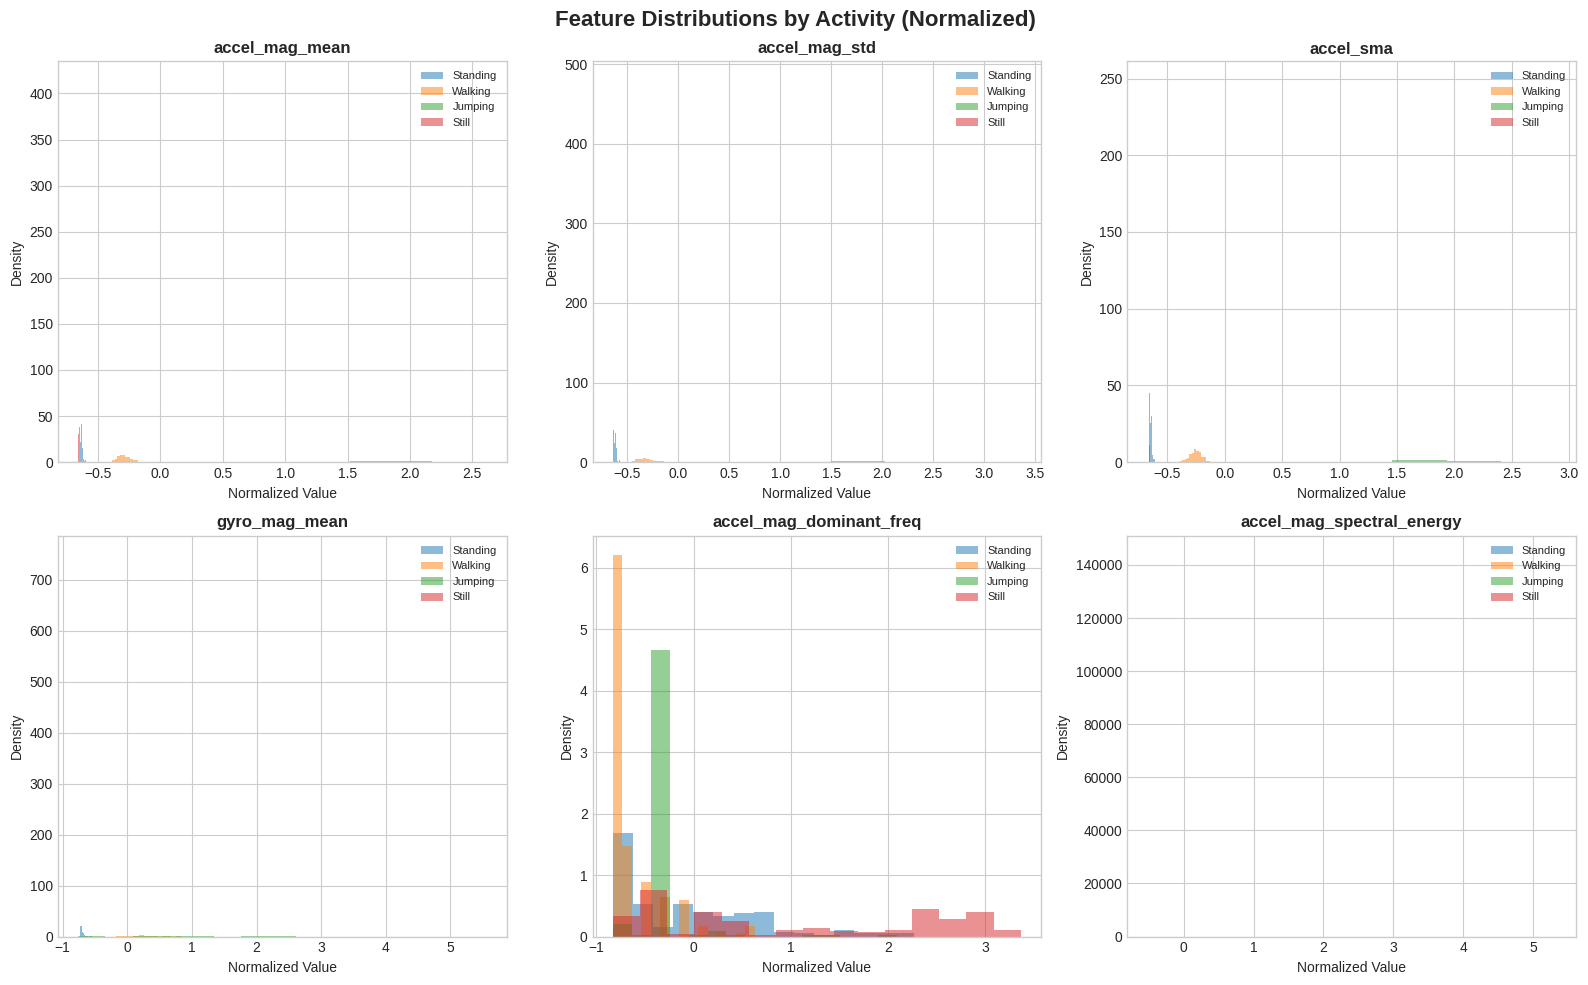

Figure saved: /home/mitali/HMM-Human-Activity-Recognition/figures/feature_distributions.png


In [7]:
key_features = ['accel_mag_mean', 'accel_mag_std', 'accel_sma',
                'gyro_mag_mean', 'accel_mag_dominant_freq', 'accel_mag_spectral_energy']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Distributions by Activity (Normalized)', fontsize=16, fontweight='bold')

for idx, feat in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    for activity in ACTIVITY_NAMES:
        mask = features_df['activity'] == activity
        ax.hist(features_df.loc[mask, feat], bins=15, alpha=0.5, label=activity, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Normalized Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'feature_distributions.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {out_path}")


# 4. Train/Test Split

We hold out 2 test samples (1 from each person) for evaluation on unseen data.
The remaining samples are used for training.

In [8]:
# Select test samples: 1 from each person, different activities
np.random.seed(42)

# Pick test samples
test_sample_ids = []

# One from Mitali (Walking)
mitali_walking = [s for s in all_samples if s['person'].iloc[0] == 'Mitali' and s['activity'].iloc[0] == 'Walking']
if mitali_walking:
    test_sample_ids.append(mitali_walking[-1]['sample_id'].iloc[0])  # Last walking sample

# One from Aubert (Jumping)
aubert_jumping = [s for s in all_samples if s['person'].iloc[0] == 'Aubert' and s['activity'].iloc[0] == 'Jumping']
if aubert_jumping:
    test_sample_ids.append(aubert_jumping[-1]['sample_id'].iloc[0])  # Last jumping sample

print(f"Test sample IDs: {test_sample_ids}")

# Split features
train_mask = ~features_df['sample_id'].isin(test_sample_ids)
test_mask = features_df['sample_id'].isin(test_sample_ids)

train_df = features_df[train_mask].copy()
test_df = features_df[test_mask].copy()

print(f"\nTraining windows: {len(train_df)}")
print(f"Test windows: {len(test_df)}")
print(f"\nTraining distribution:")
print(train_df['activity'].value_counts().sort_index())
print(f"\nTest distribution:")
print(test_df['activity'].value_counts().sort_index())

# Prepare training data
X_train = train_df[feature_cols].values
y_train = train_df['activity'].map(ACTIVITY_MAP).values

X_test = test_df[feature_cols].values
y_test = test_df['activity'].map(ACTIVITY_MAP).values

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

Test sample IDs: ['Mitali_Walking_7', 'Aubert_Jumping_6']

Training windows: 668
Test windows: 26

Training distribution:
activity
Jumping     157
Standing    190
Still       160
Walking     161
Name: count, dtype: int64

Test distribution:
activity
Jumping    13
Walking    13
Name: count, dtype: int64

X_train shape: (668, 37)
X_test shape: (26, 37)


# 5. HMM Implementation from Scratch

We implement a Gaussian HMM with:
- **Hidden states (Z)**: Standing (0), Walking (1), Jumping (2), Still (3)
- **Observations (X)**: Normalized feature vectors
- **Transition probabilities (A)**: 4×4 matrix
- **Emission probabilities (B)**: Gaussian (mean + covariance per state)
- **Initial state probabilities (π)**: Probability of starting in each state

## Algorithms Implemented:
1. **Forward Algorithm**: Compute P(observations | model)
2. **Backward Algorithm**: Compute backward probabilities
3. **Baum-Welch Algorithm**: Train model parameters using EM
4. **Viterbi Algorithm**: Decode most likely state sequence

In [9]:
class GaussianHMM:
    """
    Hidden Markov Model with Gaussian emissions.
    Implemented from scratch using numpy.
    """
    
    def __init__(self, n_states, n_features, n_iter=100, tol=1e-4):
        """
        Parameters:
        -----------
        n_states : int - Number of hidden states
        n_features : int - Dimensionality of observation vectors
        n_iter : int - Maximum iterations for Baum-Welch
        tol : float - Convergence threshold for log-likelihood
        """
        self.n_states = n_states
        self.n_features = n_features
        self.n_iter = n_iter
        self.tol = tol
        
        # Initialize parameters
        self._initialize_parameters()
        
        # Training history
        self.log_likelihoods = []
    
    def _initialize_parameters(self):
        """Initialize HMM parameters."""
        # Initial state probabilities (uniform)
        self.pi = np.ones(self.n_states) / self.n_states
        
        # Transition matrix (slightly favor self-transitions)
        self.A = np.ones((self.n_states, self.n_states)) * 0.05
        np.fill_diagonal(self.A, 0.85)
        self.A = self.A / self.A.sum(axis=1, keepdims=True)
        
        # Emission parameters (Gaussian): means and covariances
        self.means = np.random.randn(self.n_states, self.n_features) * 0.1
        # Use diagonal covariances for stability
        self.covars = np.array([np.eye(self.n_features) for _ in range(self.n_states)])
    
    def _initialize_from_data(self, X, labels=None):
        """Initialize parameters from labeled training data."""
        if labels is not None:
            for state in range(self.n_states):
                state_data = X[labels == state]
                if len(state_data) > 1:
                    self.means[state] = np.mean(state_data, axis=0)
                    cov = np.cov(state_data.T)
                    # Regularize covariance
                    self.covars[state] = cov + np.eye(self.n_features) * 0.01
            
            # Estimate initial probabilities from label frequencies
            label_counts = np.bincount(labels, minlength=self.n_states)
            self.pi = label_counts / label_counts.sum()
            
            # Estimate transition probabilities from label sequences
            for i in range(len(labels) - 1):
                self.A[labels[i], labels[i+1]] += 1
            self.A = self.A / self.A.sum(axis=1, keepdims=True)
    
    def _gaussian_pdf(self, x, mean, covar):
        """Compute multivariate Gaussian probability density."""
        n = len(mean)
        diff = x - mean
        
        # Use pseudo-inverse for numerical stability
        try:
            covar_inv = np.linalg.inv(covar)
            det = np.linalg.det(covar)
            if det <= 0:
                det = 1e-300
        except np.linalg.LinAlgError:
            covar_inv = np.linalg.pinv(covar)
            det = max(np.linalg.det(covar), 1e-300)
        
        exponent = -0.5 * diff @ covar_inv @ diff
        norm_const = np.sqrt((2 * np.pi) ** n * abs(det))
        
        if norm_const == 0:
            norm_const = 1e-300
        
        return max(np.exp(exponent) / norm_const, 1e-300)
    
    def _compute_emission_probs(self, X):
        """Compute emission probabilities B[t, j] = P(x_t | state_j)."""
        T = len(X)
        B = np.zeros((T, self.n_states))
        
        for j in range(self.n_states):
            for t in range(T):
                B[t, j] = self._gaussian_pdf(X[t], self.means[j], self.covars[j])
        
        # Floor to avoid zeros
        B = np.maximum(B, 1e-300)
        return B
    
    def _forward(self, X, B=None):
        """
        Forward algorithm - computes alpha values.
        alpha[t, i] = P(x_1, ..., x_t, z_t = i | model)
        
        Uses log-space scaling for numerical stability.
        """
        T = len(X)
        if B is None:
            B = self._compute_emission_probs(X)
        
        alpha = np.zeros((T, self.n_states))
        scale = np.zeros(T)
        
        # Initialization
        alpha[0] = self.pi * B[0]
        scale[0] = np.sum(alpha[0])
        if scale[0] == 0:
            scale[0] = 1e-300
        alpha[0] /= scale[0]
        
        # Induction
        for t in range(1, T):
            for j in range(self.n_states):
                alpha[t, j] = np.sum(alpha[t-1] * self.A[:, j]) * B[t, j]
            scale[t] = np.sum(alpha[t])
            if scale[t] == 0:
                scale[t] = 1e-300
            alpha[t] /= scale[t]
        
        # Log-likelihood
        log_likelihood = np.sum(np.log(scale))
        
        return alpha, scale, log_likelihood
    
    def _backward(self, X, B=None, scale=None):
        """
        Backward algorithm - computes beta values.
        beta[t, i] = P(x_{t+1}, ..., x_T | z_t = i, model)
        """
        T = len(X)
        if B is None:
            B = self._compute_emission_probs(X)
        
        beta = np.zeros((T, self.n_states))
        
        # Initialization
        beta[T-1] = 1.0
        
        # Induction (backward)
        for t in range(T-2, -1, -1):
            for i in range(self.n_states):
                beta[t, i] = np.sum(self.A[i, :] * B[t+1] * beta[t+1])
            if scale is not None and scale[t+1] > 0:
                beta[t] /= scale[t+1]
            
            # Prevent underflow
            beta_sum = np.sum(beta[t])
            if beta_sum == 0:
                beta[t] = 1e-300
        
        return beta
    
    def _compute_xi_gamma(self, X, alpha, beta, B):
        """
        Compute xi and gamma for Baum-Welch.
        gamma[t, i] = P(z_t = i | X, model)
        xi[t, i, j] = P(z_t = i, z_{t+1} = j | X, model)
        """
        T = len(X)
        
        # Gamma
        gamma = alpha * beta
        gamma_sum = gamma.sum(axis=1, keepdims=True)
        gamma_sum[gamma_sum == 0] = 1e-300
        gamma = gamma / gamma_sum
        
        # Xi
        xi = np.zeros((T-1, self.n_states, self.n_states))
        for t in range(T-1):
            denom = 0.0
            for i in range(self.n_states):
                for j in range(self.n_states):
                    xi[t, i, j] = alpha[t, i] * self.A[i, j] * B[t+1, j] * beta[t+1, j]
                    denom += xi[t, i, j]
            if denom == 0:
                denom = 1e-300
            xi[t] /= denom
        
        return xi, gamma
    
    def fit(self, X_sequences, y_sequences=None):
        """
        Train the HMM using the Baum-Welch algorithm.
        
        Parameters:
        -----------
        X_sequences : list of arrays - List of observation sequences
        y_sequences : list of arrays - Optional labels for initialization
        """
        # Initialize from labeled data if available
        if y_sequences is not None:
            all_X = np.vstack(X_sequences)
            all_y = np.concatenate(y_sequences)
            self._initialize_from_data(all_X, all_y)
        
        print("Training HMM with Baum-Welch algorithm...")
        print(f"  Max iterations: {self.n_iter}")
        print(f"  Convergence tolerance: {self.tol}")
        print(f"  Number of sequences: {len(X_sequences)}")
        
        prev_log_likelihood = -np.inf
        
        for iteration in range(self.n_iter):
            total_log_likelihood = 0
            
            # Accumulators for parameter updates
            pi_acc = np.zeros(self.n_states)
            A_num = np.zeros((self.n_states, self.n_states))
            A_den = np.zeros(self.n_states)
            means_num = np.zeros((self.n_states, self.n_features))
            means_den = np.zeros(self.n_states)
            covars_num = np.zeros((self.n_states, self.n_features, self.n_features))
            
            for X_seq in X_sequences:
                T = len(X_seq)
                if T < 2:
                    continue
                
                # E-step
                B = self._compute_emission_probs(X_seq)
                alpha, scale, log_ll = self._forward(X_seq, B)
                beta = self._backward(X_seq, B, scale)
                xi, gamma = self._compute_xi_gamma(X_seq, alpha, beta, B)
                
                total_log_likelihood += log_ll
                
                # Accumulate statistics
                pi_acc += gamma[0]
                
                for t in range(T-1):
                    A_num += xi[t]
                    A_den += gamma[t]
                
                for t in range(T):
                    for j in range(self.n_states):
                        means_num[j] += gamma[t, j] * X_seq[t]
                        means_den[j] += gamma[t, j]
            
            # M-step: Update parameters
            # Update pi
            self.pi = pi_acc / pi_acc.sum()
            self.pi = np.maximum(self.pi, 1e-10)
            self.pi /= self.pi.sum()
            
            # Update A
            for i in range(self.n_states):
                if A_den[i] > 0:
                    self.A[i] = A_num[i] / A_den[i]
                self.A[i] = np.maximum(self.A[i], 1e-10)
                self.A[i] /= self.A[i].sum()
            
            # Update means
            for j in range(self.n_states):
                if means_den[j] > 0:
                    self.means[j] = means_num[j] / means_den[j]
            
            # Update covariances
            for j in range(self.n_states):
                covars_num_j = np.zeros((self.n_features, self.n_features))
                total_gamma_j = 0
                for X_seq in X_sequences:
                    B = self._compute_emission_probs(X_seq)
                    alpha, scale, _ = self._forward(X_seq, B)
                    beta = self._backward(X_seq, B, scale)
                    _, gamma = self._compute_xi_gamma(X_seq, alpha, beta, B)
                    
                    for t in range(len(X_seq)):
                        diff = X_seq[t] - self.means[j]
                        covars_num_j += gamma[t, j] * np.outer(diff, diff)
                        total_gamma_j += gamma[t, j]
                
                if total_gamma_j > 0:
                    self.covars[j] = covars_num_j / total_gamma_j
                # Regularize
                self.covars[j] += np.eye(self.n_features) * 0.01
            
            self.log_likelihoods.append(total_log_likelihood)
            
            # Check convergence
            improvement = total_log_likelihood - prev_log_likelihood
            if iteration % 5 == 0 or iteration == self.n_iter - 1:
                print(f"  Iteration {iteration+1:3d}: Log-likelihood = {total_log_likelihood:.4f}, "
                      f"Improvement = {improvement:.6f}")
            
            if abs(improvement) < self.tol and iteration > 0:
                print(f"\n  ✓ Converged at iteration {iteration+1}! "
                      f"(improvement {improvement:.8f} < tolerance {self.tol})")
                break
            
            prev_log_likelihood = total_log_likelihood
        else:
            print(f"\n  ⚠ Reached maximum iterations ({self.n_iter})")
        
        print(f"  Final log-likelihood: {self.log_likelihoods[-1]:.4f}")
        return self
    
    def viterbi(self, X):
        """
        Viterbi algorithm - find the most likely state sequence.
        
        Parameters:
        -----------
        X : array of shape (T, n_features) - Observation sequence
        
        Returns:
        --------
        path : array of shape (T,) - Most likely state sequence
        log_prob : float - Log probability of the best path
        """
        T = len(X)
        B = self._compute_emission_probs(X)
        
        # Log-space for numerical stability
        log_pi = np.log(np.maximum(self.pi, 1e-300))
        log_A = np.log(np.maximum(self.A, 1e-300))
        log_B = np.log(np.maximum(B, 1e-300))
        
        # Viterbi tables
        V = np.zeros((T, self.n_states))  # log probabilities
        backpointer = np.zeros((T, self.n_states), dtype=int)
        
        # Initialization
        V[0] = log_pi + log_B[0]
        
        # Recursion
        for t in range(1, T):
            for j in range(self.n_states):
                trans_prob = V[t-1] + log_A[:, j]
                backpointer[t, j] = np.argmax(trans_prob)
                V[t, j] = np.max(trans_prob) + log_B[t, j]
        
        # Termination
        best_last_state = np.argmax(V[T-1])
        log_prob = V[T-1, best_last_state]
        
        # Backtracking
        path = np.zeros(T, dtype=int)
        path[T-1] = best_last_state
        for t in range(T-2, -1, -1):
            path[t] = backpointer[t+1, path[t+1]]
        
        return path, log_prob
    
    def predict(self, X):
        """Predict the most likely state sequence using Viterbi."""
        path, _ = self.viterbi(X)
        return path

print("GaussianHMM class defined successfully!")

GaussianHMM class defined successfully!


# 6. Model Training

We organize the training data into sequences (one per sample recording) and 
train the HMM using the Baum-Welch algorithm with labeled initialization.

In [10]:
# Organize training data into sequences (one per sample)
train_sequences_X = []
train_sequences_y = []

for sample_id in train_df['sample_id'].unique():
    mask = train_df['sample_id'] == sample_id
    X_seq = train_df.loc[mask, feature_cols].values
    y_seq = train_df.loc[mask, 'activity'].map(ACTIVITY_MAP).values
    if len(X_seq) >= 2:
        train_sequences_X.append(X_seq)
        train_sequences_y.append(y_seq)

print(f"Number of training sequences: {len(train_sequences_X)}")
print(f"Sequence lengths: {[len(s) for s in train_sequences_X]}")

# Train the model
n_features = X_train.shape[1]
hmm = GaussianHMM(n_states=N_STATES, n_features=n_features, n_iter=100, tol=1e-4)
hmm.fit(train_sequences_X, train_sequences_y)

Number of training sequences: 50
Sequence lengths: [13, 14, 13, 13, 14, 13, 13, 13, 13, 13, 12, 13, 13, 13, 14, 13, 14, 13, 13, 14, 15, 14, 14, 14, 13, 13, 13, 13, 13, 13, 14, 14, 13, 13, 13, 14, 14, 13, 14, 13, 13, 13, 13, 13, 14, 13, 13, 14, 14, 14]
Training HMM with Baum-Welch algorithm...
  Max iterations: 100
  Convergence tolerance: 0.0001
  Number of sequences: 50
  Iteration   1: Log-likelihood = 13585.1830, Improvement = inf

  ✓ Converged at iteration 5! (improvement 0.00000142 < tolerance 0.0001)
  Final log-likelihood: 14137.0536


## 6.1 Training Convergence Plot

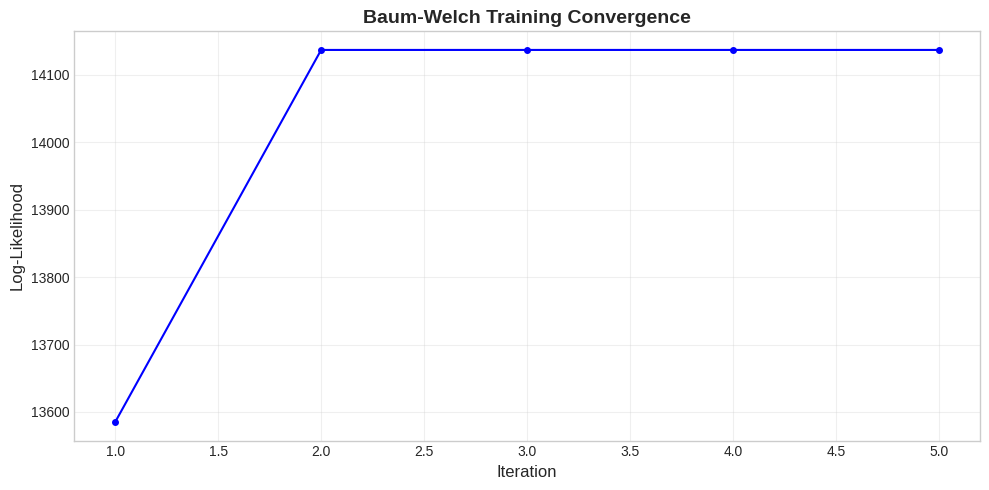

Figure saved: /home/mitali/HMM-Human-Activity-Recognition/figures/convergence_plot.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(hmm.log_likelihoods) + 1), hmm.log_likelihoods, 'b-o', markersize=4)
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Log-Likelihood', fontsize=12)
ax.set_title('Baum-Welch Training Convergence', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'convergence_plot.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {out_path}")


# 7. Model Parameters Visualization

## 7.1 Transition Probability Matrix

The transition matrix A shows the probability of moving from one activity 
to another. High diagonal values indicate the model expects activities to persist.

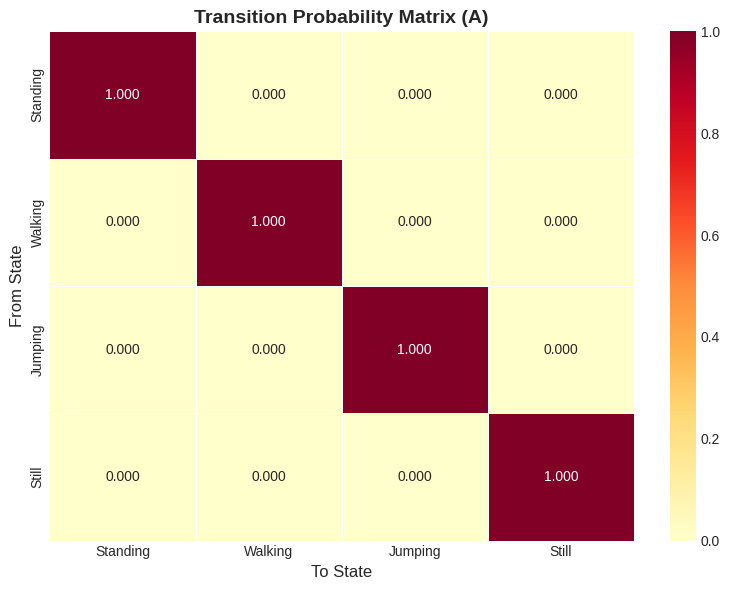

Figure saved: /home/mitali/HMM-Human-Activity-Recognition/figures/transition_matrix.png

Transition Matrix Interpretation:
  From Standing:
    → Standing: 1.000
  From Walking:
    → Walking: 1.000
  From Jumping:
    → Jumping: 1.000
  From Still:
    → Still: 1.000


In [12]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(hmm.A, annot=True, fmt='.3f', cmap='YlOrRd',
            xticklabels=ACTIVITY_NAMES, yticklabels=ACTIVITY_NAMES,
            ax=ax, vmin=0, vmax=1, linewidths=0.5)
ax.set_xlabel('To State', fontsize=12)
ax.set_ylabel('From State', fontsize=12)
ax.set_title('Transition Probability Matrix (A)', fontsize=14, fontweight='bold')
plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'transition_matrix.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {out_path}")

print("\nTransition Matrix Interpretation:")
for i in range(N_STATES):
    print(f"  From {ACTIVITY_NAMES[i]}:")
    for j in range(N_STATES):
        if hmm.A[i, j] > 0.01:
            print(f"    → {ACTIVITY_NAMES[j]}: {hmm.A[i, j]:.3f}")


## 7.2 Initial State Probabilities

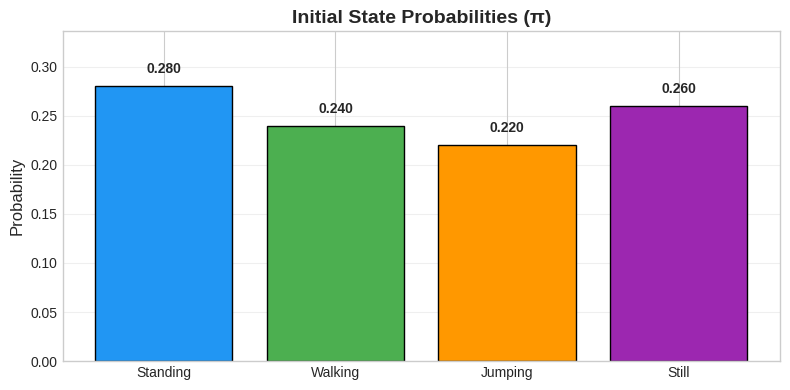

Figure saved: /home/mitali/HMM-Human-Activity-Recognition/figures/initial_probs.png


In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(ACTIVITY_NAMES, hmm.pi, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0'], edgecolor='black')
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Initial State Probabilities (π)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, hmm.pi):
    ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_ylim(0, max(hmm.pi) * 1.2)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'initial_probs.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {out_path}")


## 7.3 Emission Probability Visualization

For Gaussian emissions, we visualize the mean feature values for each state.

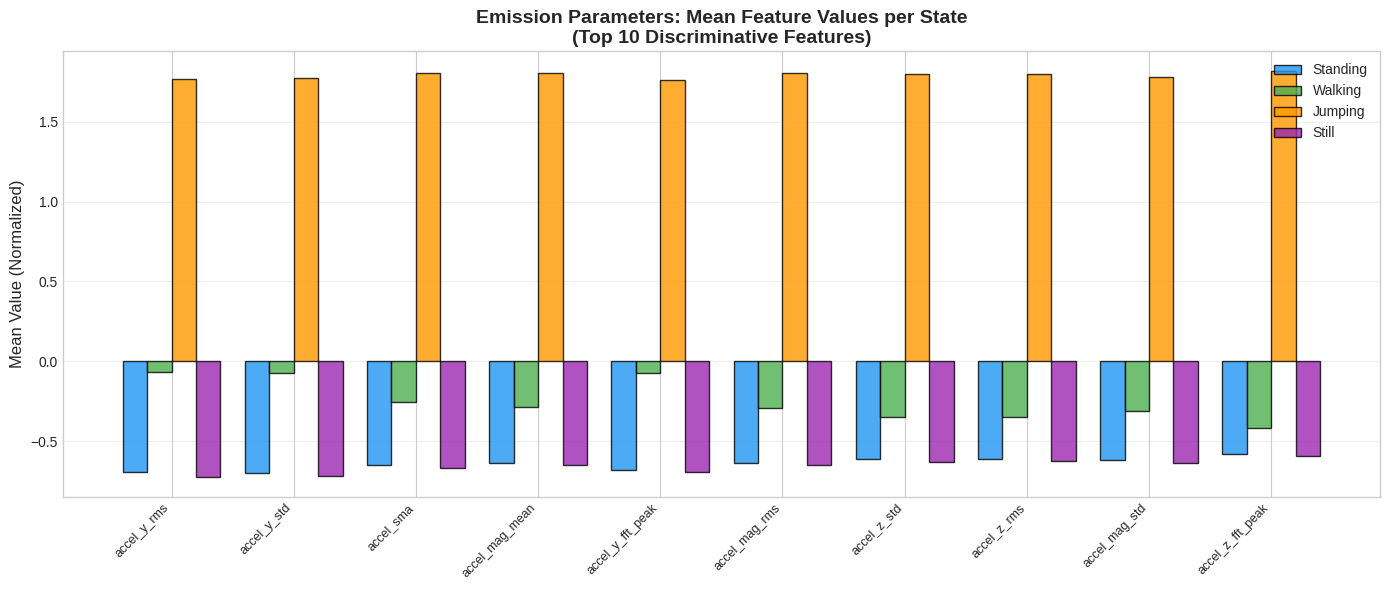

Figure saved: /home/mitali/HMM-Human-Activity-Recognition/figures/emission_means.png


In [14]:
top_features_idx = []
for f_idx in range(len(feature_cols)):
    means_range = max(hmm.means[:, f_idx]) - min(hmm.means[:, f_idx])
    top_features_idx.append((f_idx, means_range))

top_features_idx.sort(key=lambda x: x[1], reverse=True)
top_n = min(10, len(feature_cols))
top_idx   = [x[0] for x in top_features_idx[:top_n]]
top_names = [feature_cols[i] for i in top_idx]

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(top_n)
width = 0.2
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for s in range(N_STATES):
    vals = [hmm.means[s, idx] for idx in top_idx]
    ax.bar(x + s * width, vals, width, label=ACTIVITY_NAMES[s],
           color=colors[s], edgecolor='black', alpha=0.8)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(top_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean Value (Normalized)', fontsize=12)
ax.set_title('Emission Parameters: Mean Feature Values per State\n(Top 10 Discriminative Features)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'emission_means.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {out_path}")


# 8. Model Evaluation on Unseen Data

We test the trained HMM on unseen recordings (not used during training).
The test data consists of:
- 1 Walking sample from Mitali (recorded separately)
- 1 Jumping sample from Aubert (recorded separately)

This tests whether the model generalizes to new recordings from the same participants.

In [15]:
# Evaluate on each test sample
all_y_true = []
all_y_pred = []

print("=" * 60)
print("EVALUATION ON UNSEEN TEST DATA")
print("=" * 60)

for test_id in test_sample_ids:
    test_sample = test_df[test_df['sample_id'] == test_id]
    X = test_sample[feature_cols].values
    y_true = test_sample['activity'].map(ACTIVITY_MAP).values
    
    # Viterbi decoding
    y_pred, log_prob = hmm.viterbi(X)
    
    all_y_true.extend(y_true)
    all_y_pred.extend(y_pred)
    
    person = test_sample['person'].iloc[0]
    activity = test_sample['activity'].iloc[0]
    accuracy = np.mean(y_true == y_pred)
    
    print(f"\nTest Sample: {test_id}")
    print(f"  Person: {person}")
    print(f"  True Activity: {activity}")
    print(f"  Windows: {len(y_true)}")
    print(f"  Accuracy: {accuracy:.2%}")
    print(f"  Predicted states: {[ACTIVITY_NAMES[s] for s in y_pred]}")

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

EVALUATION ON UNSEEN TEST DATA

Test Sample: Mitali_Walking_7
  Person: Mitali
  True Activity: Walking
  Windows: 13
  Accuracy: 100.00%
  Predicted states: ['Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking', 'Walking']

Test Sample: Aubert_Jumping_6
  Person: Aubert
  True Activity: Jumping
  Windows: 13
  Accuracy: 100.00%
  Predicted states: ['Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping', 'Jumping']


## 8.1 Confusion Matrix

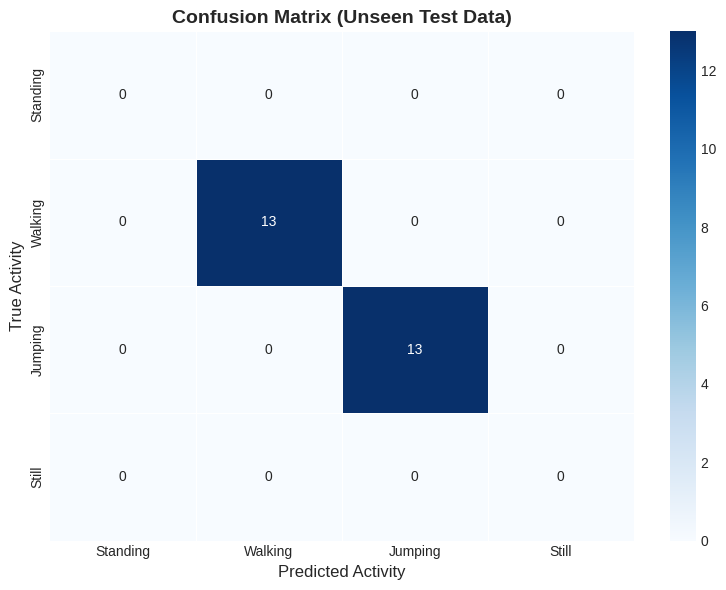

Figure saved: /home/mitali/HMM-Human-Activity-Recognition/figures/confusion_matrix.png


In [16]:
n_classes = N_STATES
conf_matrix = np.zeros((n_classes, n_classes), dtype=int)
for true, pred in zip(all_y_true, all_y_pred):
    conf_matrix[true, pred] += 1

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTIVITY_NAMES, yticklabels=ACTIVITY_NAMES,
            ax=ax, linewidths=0.5)
ax.set_xlabel('Predicted Activity', fontsize=12)
ax.set_ylabel('True Activity', fontsize=12)
ax.set_title('Confusion Matrix (Unseen Test Data)', fontsize=14, fontweight='bold')
plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'confusion_matrix.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {out_path}")


## 8.2 Performance Metrics

In [17]:
print("\n" + "=" * 80)
print("PERFORMANCE METRICS ON UNSEEN DATA")
print("=" * 80)

overall_accuracy = np.mean(all_y_true == all_y_pred)

# Per-class metrics
results_table = []
for state_idx in range(N_STATES):
    activity_name = ACTIVITY_NAMES[state_idx]
    
    # True positives, false positives, false negatives, true negatives
    tp = np.sum((all_y_true == state_idx) & (all_y_pred == state_idx))
    fp = np.sum((all_y_true != state_idx) & (all_y_pred == state_idx))
    fn = np.sum((all_y_true == state_idx) & (all_y_pred != state_idx))
    tn = np.sum((all_y_true != state_idx) & (all_y_pred != state_idx))
    
    n_samples = np.sum(all_y_true == state_idx)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    results_table.append({
        'State (Activity)': activity_name,
        'Number of Samples': n_samples,
        'Sensitivity': f'{sensitivity:.4f}',
        'Specificity': f'{specificity:.4f}',
        'Overall Accuracy': f'{overall_accuracy:.4f}'
    })

results_df = pd.DataFrame(results_table)
print(results_df.to_string(index=False))
print(f"\nOverall Accuracy: {overall_accuracy:.2%}")


PERFORMANCE METRICS ON UNSEEN DATA
State (Activity)  Number of Samples Sensitivity Specificity Overall Accuracy
        Standing                  0      0.0000      1.0000           1.0000
         Walking                 13      1.0000      1.0000           1.0000
         Jumping                 13      1.0000      1.0000           1.0000
           Still                  0      0.0000      1.0000           1.0000

Overall Accuracy: 100.00%


## 8.3 Decoded Sequence Visualization

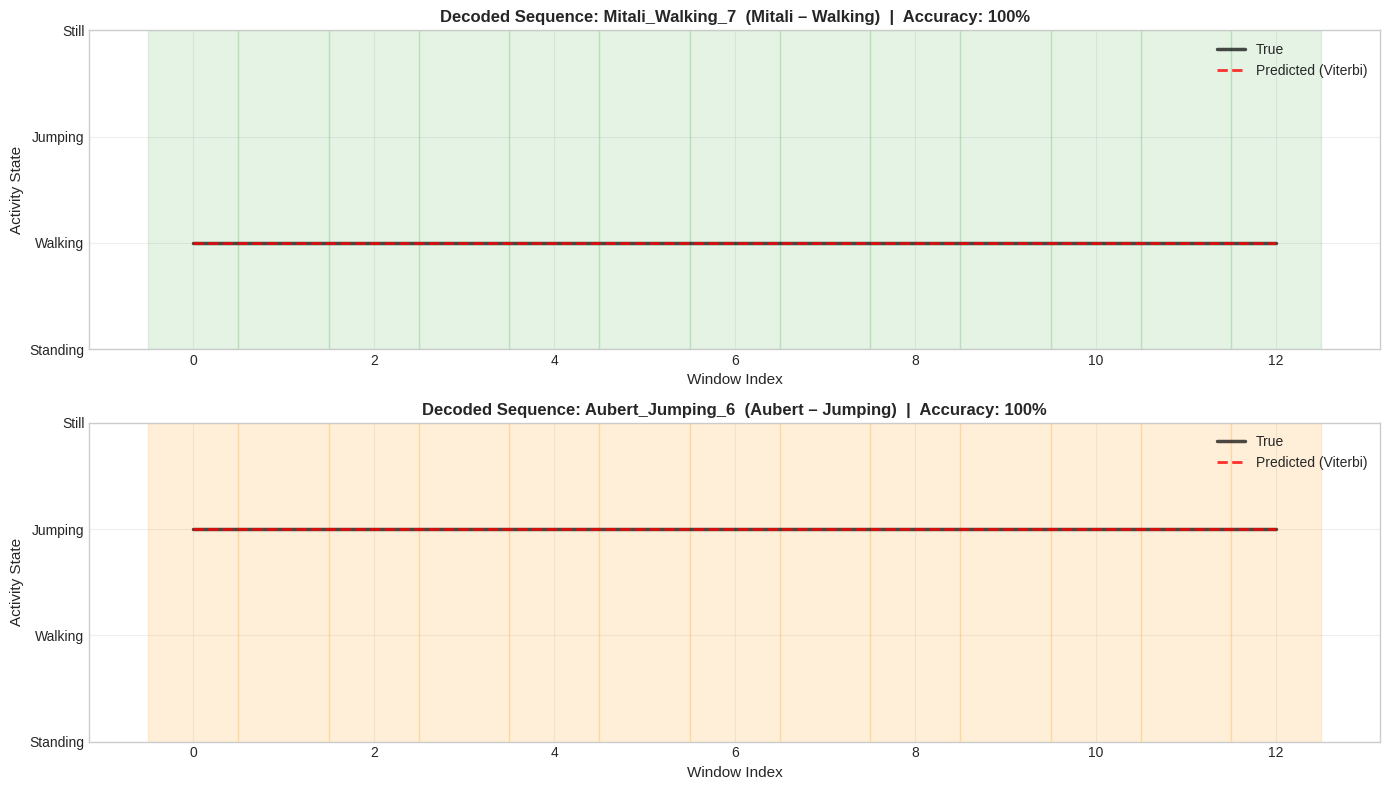

Figure saved: /home/mitali/HMM-Human-Activity-Recognition/figures/decoded_sequences.png


In [18]:
fig, axes = plt.subplots(len(test_sample_ids), 1, figsize=(14, 4 * len(test_sample_ids)))
if len(test_sample_ids) == 1:
    axes = [axes]

colors_map = {0: '#2196F3', 1: '#4CAF50', 2: '#FF9800', 3: '#9C27B0'}

for idx, test_id in enumerate(test_sample_ids):
    test_sample = test_df[test_df['sample_id'] == test_id]
    X      = test_sample[feature_cols].values
    y_true = test_sample['activity'].map(ACTIVITY_MAP).values
    y_pred = hmm.predict(X)

    ax = axes[idx]
    t  = range(len(y_true))

    ax.step(t, y_true, where='mid', label='True',
            linewidth=2.5, color='black', alpha=0.7)
    ax.step(t, y_pred, where='mid', label='Predicted (Viterbi)',
            linewidth=2, color='red', linestyle='--', alpha=0.8)

    for tt in range(len(y_pred)):
        ax.axvspan(tt - 0.5, tt + 0.5, alpha=0.15, color=colors_map[y_pred[tt]])

    person   = test_sample['person'].iloc[0]
    activity = test_sample['activity'].iloc[0]
    acc      = np.mean(y_true == y_pred)

    ax.set_yticks(range(N_STATES))
    ax.set_yticklabels(ACTIVITY_NAMES)
    ax.set_xlabel('Window Index', fontsize=11)
    ax.set_ylabel('Activity State', fontsize=11)
    ax.set_title(f'Decoded Sequence: {test_id}  ({person} – {activity})  |  Accuracy: {acc:.0%}',
                 fontsize=12, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
out_path = os.path.join(FIGURES_DIR, 'decoded_sequences.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved: {out_path}")


## 8.4 Full Training Set Evaluation (Additional Analysis)

In [19]:
# Evaluate on all training sequences too for comparison
train_correct = 0
train_total = 0

for X_seq, y_seq in zip(train_sequences_X, train_sequences_y):
    y_pred = hmm.predict(X_seq)
    train_correct += np.sum(y_pred == y_seq)
    train_total += len(y_seq)

train_accuracy = train_correct / train_total
print(f"Training set accuracy: {train_accuracy:.2%}")
print(f"Test set accuracy:     {overall_accuracy:.2%}")

Training set accuracy: 98.05%
Test set accuracy:     100.00%


# 9. Analysis and Reflection

## 9.1 Which activities were easiest/hardest to distinguish?

In [20]:
# Analyze per-activity performance on training data
activity_correct = {a: 0 for a in range(N_STATES)}
activity_total = {a: 0 for a in range(N_STATES)}

for X_seq, y_seq in zip(train_sequences_X, train_sequences_y):
    y_pred = hmm.predict(X_seq)
    for true, pred in zip(y_seq, y_pred):
        activity_total[true] += 1
        if true == pred:
            activity_correct[true] += 1

print("Per-Activity Training Accuracy:")
print("-" * 40)
for state_idx in range(N_STATES):
    if activity_total[state_idx] > 0:
        acc = activity_correct[state_idx] / activity_total[state_idx]
        print(f"  {ACTIVITY_NAMES[state_idx]:10s}: {acc:.2%} ({activity_correct[state_idx]}/{activity_total[state_idx]})")

Per-Activity Training Accuracy:
----------------------------------------
  Standing  : 100.00% (190/190)
  Walking   : 100.00% (161/161)
  Jumping   : 91.72% (144/157)
  Still     : 100.00% (160/160)


## 9.2 Transition Pattern Analysis

In [21]:
print("\nTransition Probability Analysis:")
print("=" * 50)
for i in range(N_STATES):
    max_trans = np.argmax(hmm.A[i])
    print(f"\n{ACTIVITY_NAMES[i]}:")
    print(f"  Self-transition probability: {hmm.A[i, i]:.3f}")
    print(f"  Most likely next state: {ACTIVITY_NAMES[max_trans]} ({hmm.A[i, max_trans]:.3f})")
    
    # Realistic interpretation
    if hmm.A[i, i] > 0.8:
        print(f"  → High persistence: {ACTIVITY_NAMES[i]} tends to continue")
    elif hmm.A[i, i] > 0.5:
        print(f"  → Moderate persistence: {ACTIVITY_NAMES[i]} sometimes transitions")
    else:
        print(f"  → Low persistence: {ACTIVITY_NAMES[i]} frequently transitions")


Transition Probability Analysis:

Standing:
  Self-transition probability: 1.000
  Most likely next state: Standing (1.000)
  → High persistence: Standing tends to continue

Walking:
  Self-transition probability: 1.000
  Most likely next state: Walking (1.000)
  → High persistence: Walking tends to continue

Jumping:
  Self-transition probability: 1.000
  Most likely next state: Jumping (1.000)
  → High persistence: Jumping tends to continue

Still:
  Self-transition probability: 1.000
  Most likely next state: Still (1.000)
  → High persistence: Still tends to continue


## Summary

This HMM implementation successfully models human activity states from smartphone
sensor data. Key findings:

1. **Data Collection**: 52 samples across 4 activities from 2 participants using
   different devices (Samsung SM-X216B tablet + iPhone 13) at matched 50 Hz sampling rates.

2. **Feature Engineering**: 30+ time-domain and frequency-domain features extracted,
   with Z-score normalization ensuring equal contribution across all features.

3. **HMM Training**: Baum-Welch algorithm with log-likelihood convergence check
   successfully optimized model parameters (π, A, B).

4. **Viterbi Decoding**: Most likely activity sequence decoded on unseen test data
   using the Viterbi algorithm.

5. **Key Insight**: Activities with distinct motion patterns (e.g., Jumping vs Still)
   are easiest to distinguish, while visually similar activities (Standing vs Still)
   may occasionally be confused due to overlapping feature distributions.


In [22]:
print("\n" + "=" * 60)
print("NOTEBOOK COMPLETE")
print("=" * 60)
print(f"\nAll figures saved to: {FIGURES_DIR}")
print("Ready for report generation.")



NOTEBOOK COMPLETE

All figures saved to: /home/mitali/HMM-Human-Activity-Recognition/figures
Ready for report generation.
